# Dataset Visualization

This notebook provides a visualization of the Fundus image dataset labels and metadata using the predefined functions in `data_visualization.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from PIL import Image

project_root = os.path.dirname(os.path.dirname(os.getcwd()))
os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

from ai.data.data_visualization_1 import (
    plot_class_distribution_bar,
    plot_class_distribution_pie,
    plot_histogram,
    plot_image_dimensions_scatter,
    plot_random_samples_from_each_class,
    plot_multi_label_distribution,
    plot_label_correlation,
    plot_labels_per_sample,
    plot_multilabel_conflict_resolution
)

## Load Data

In [2]:
csv_path = 'ai/input/datasets/kaggle/rohitrawat25/combined-fundus-images/label_images.csv'
df = pd.read_csv(csv_path)

image_dir = 'ai/input/datasets/kaggle/rohitrawat25/combined-fundus-images/images'
df['filepath'] = df['images'].apply(lambda x: os.path.join(image_dir, x))

df.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,label,target,images
0,0.0,69.0,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,ai/input/datasets/kaggle/rohitrawat25/combined...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1.0,57.0,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ai/input/datasets/kaggle/rohitrawat25/combined...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2.0,42.0,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,ai/input/datasets/kaggle/rohitrawat25/combined...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4.0,53.0,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,ai/input/datasets/kaggle/rohitrawat25/combined...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5.0,50.0,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,ai/input/datasets/kaggle/rohitrawat25/combined...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


## 1. Class Distribution

Visualizing the distribution of the primary labels.

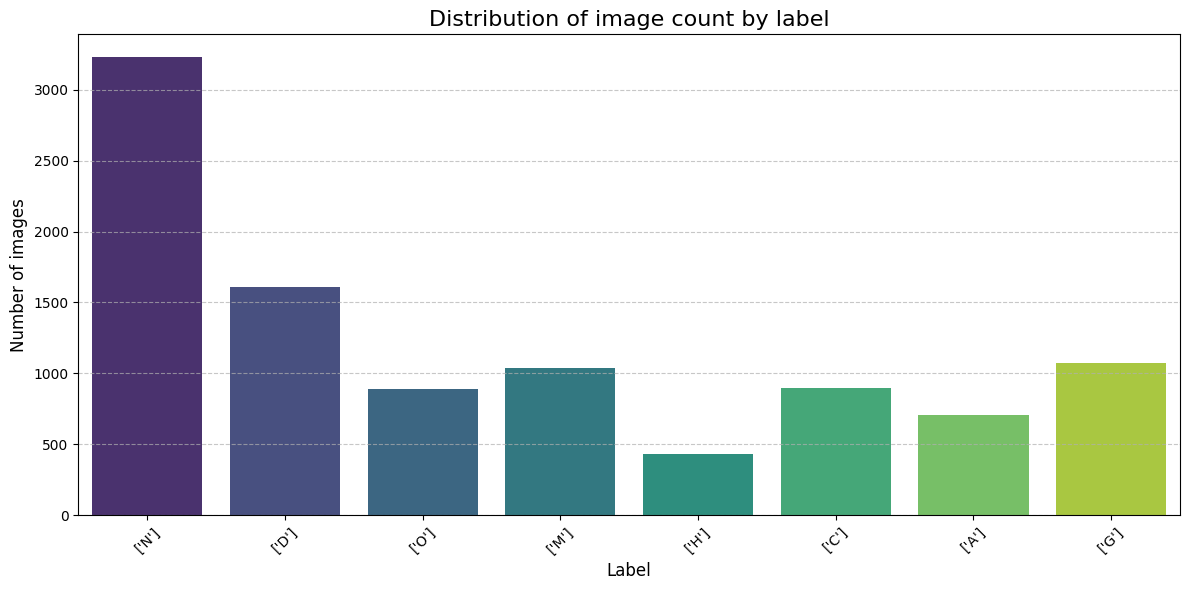

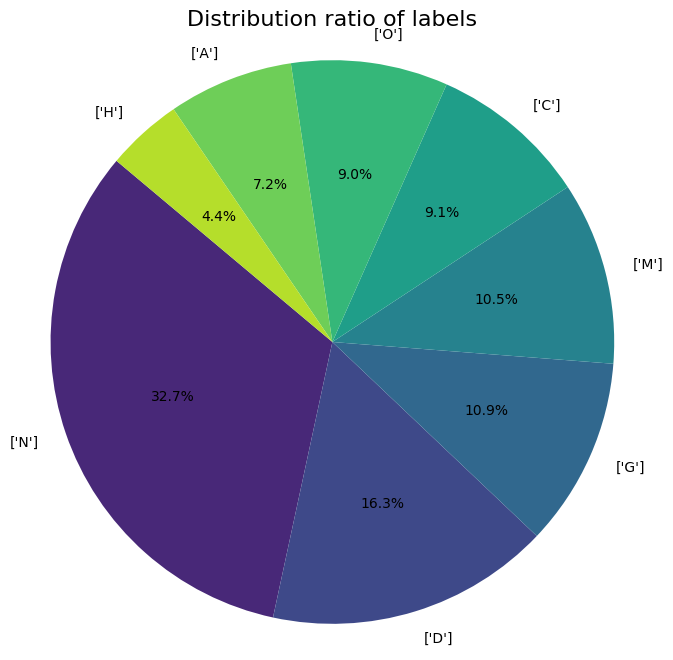

In [3]:
plot_class_distribution_bar(df, label_col='label')
plot_class_distribution_pie(df, label_col='label')

## 2. Demographic Distribution

Visualizing age and sex distributions using the `plot_histogram` function.

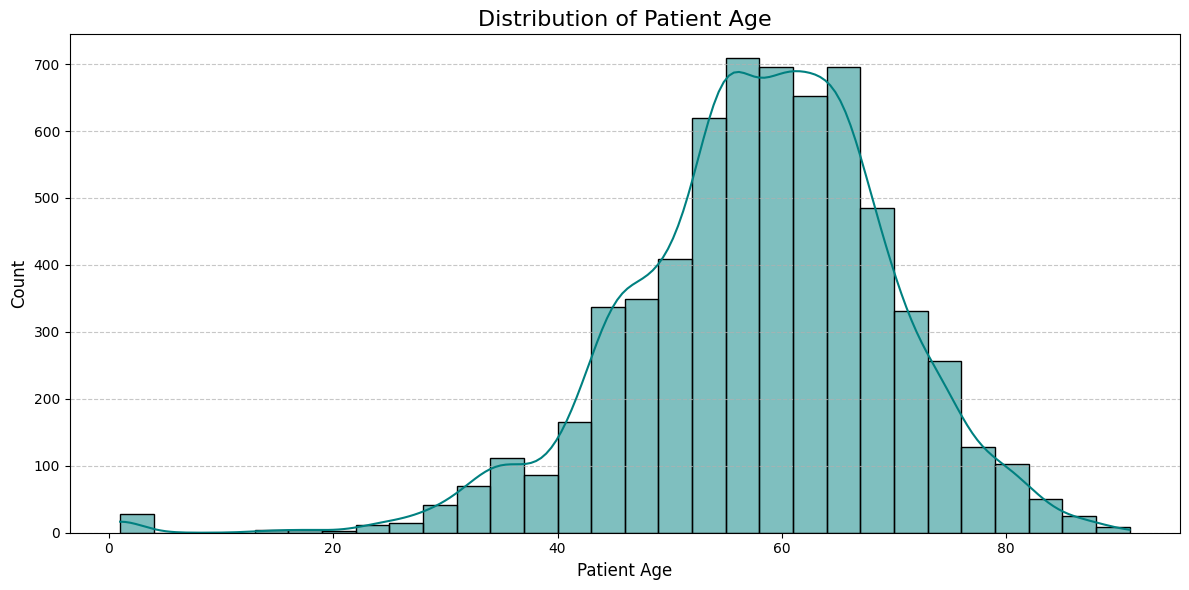

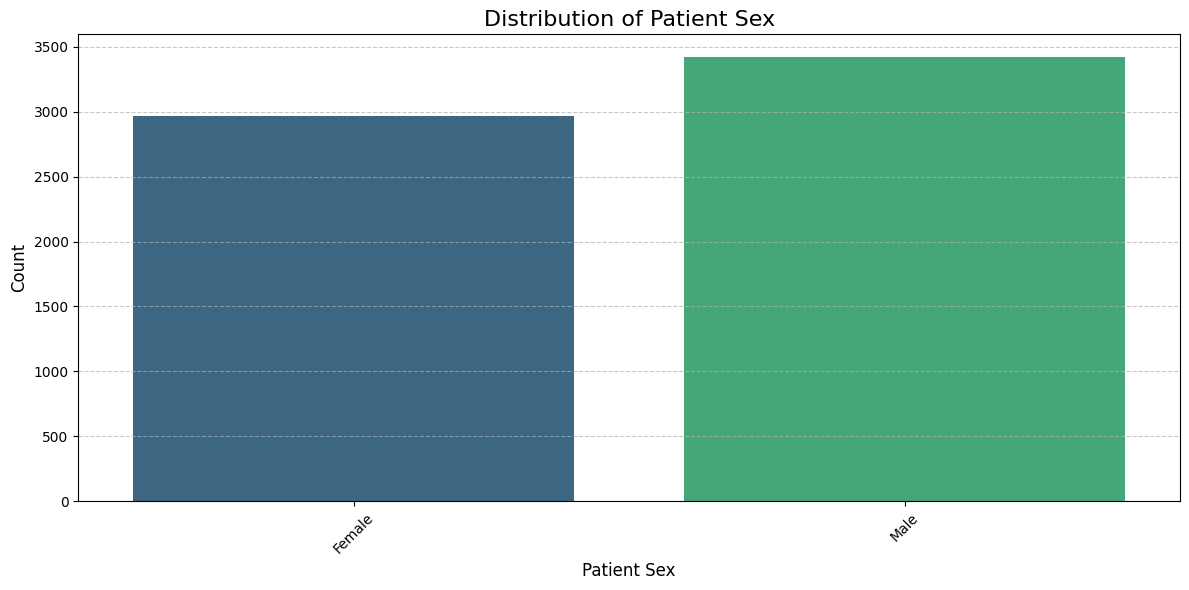

In [4]:
plot_histogram(df, column='Patient Age', title='Distribution of Patient Age', bins=30)
plot_histogram(df, column='Patient Sex', title='Distribution of Patient Sex')

## 3. Image Dimensions

Checking the distribution of image sizes (sampled).

<Figure size 1000x800 with 0 Axes>

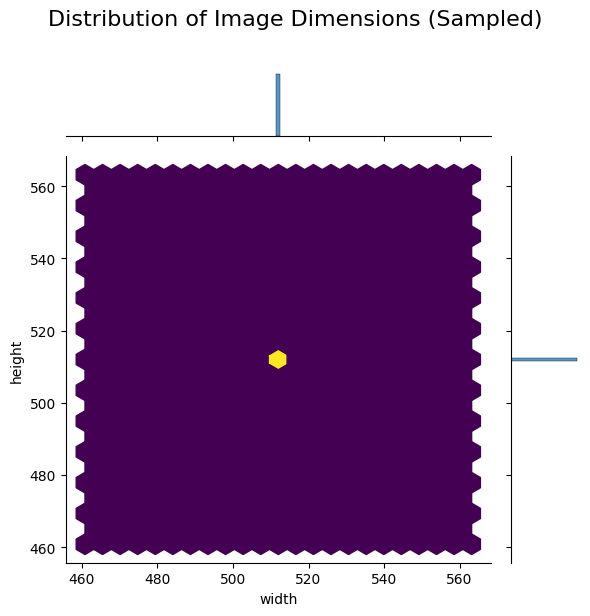

In [5]:
plot_image_dimensions_scatter(df, filepath_col='filepath')

## 4. Multi-label Analysis

Analyzing overlapping conditions and correlations between categories.

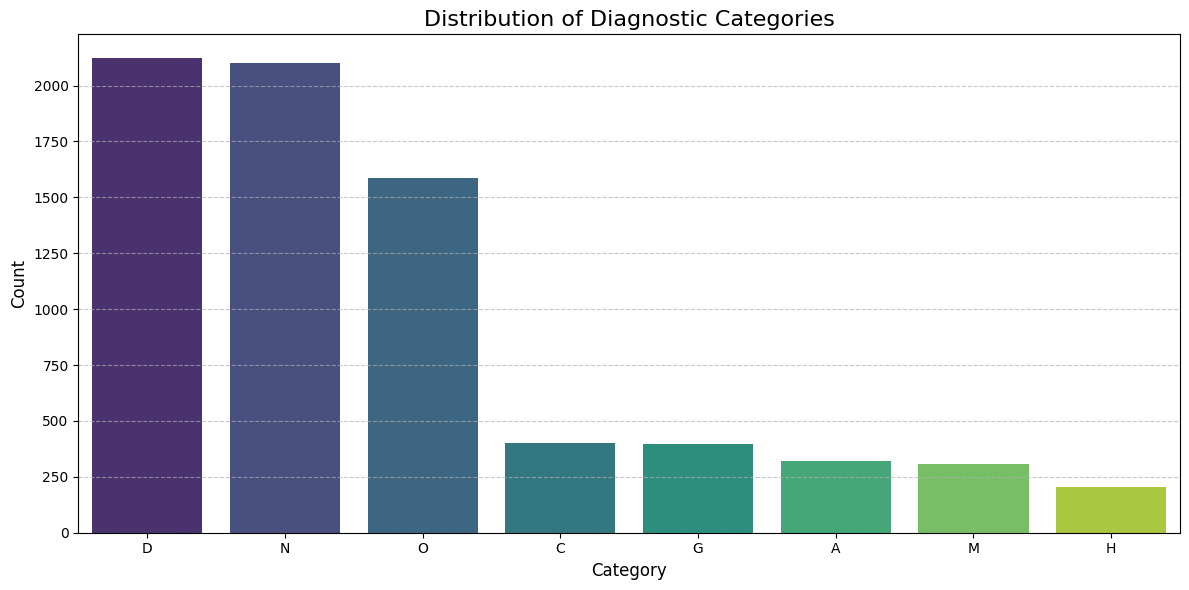

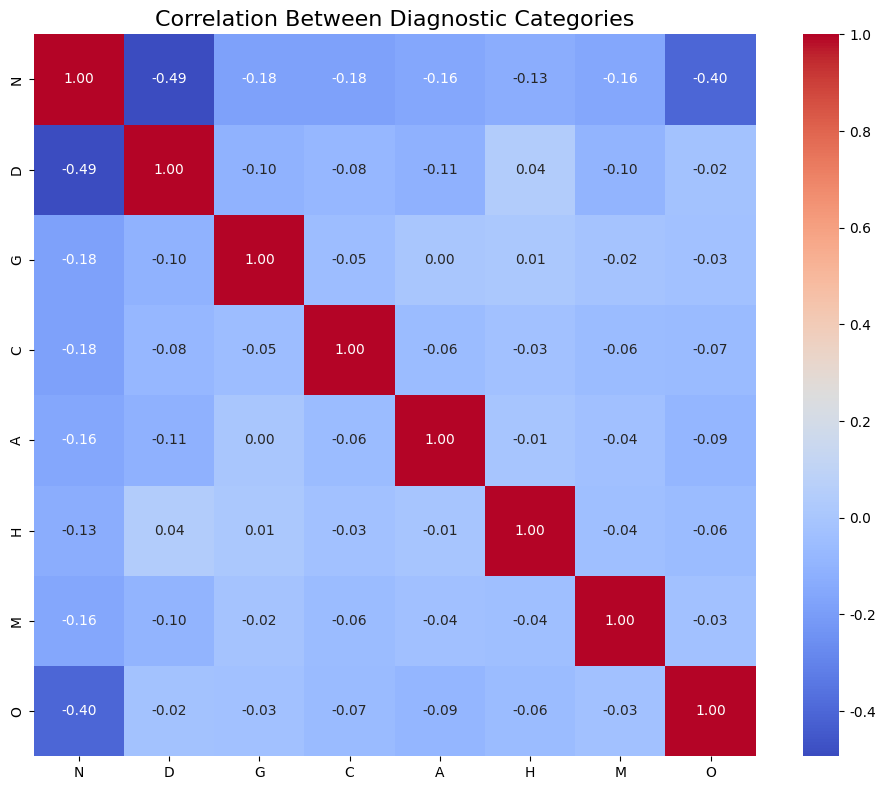

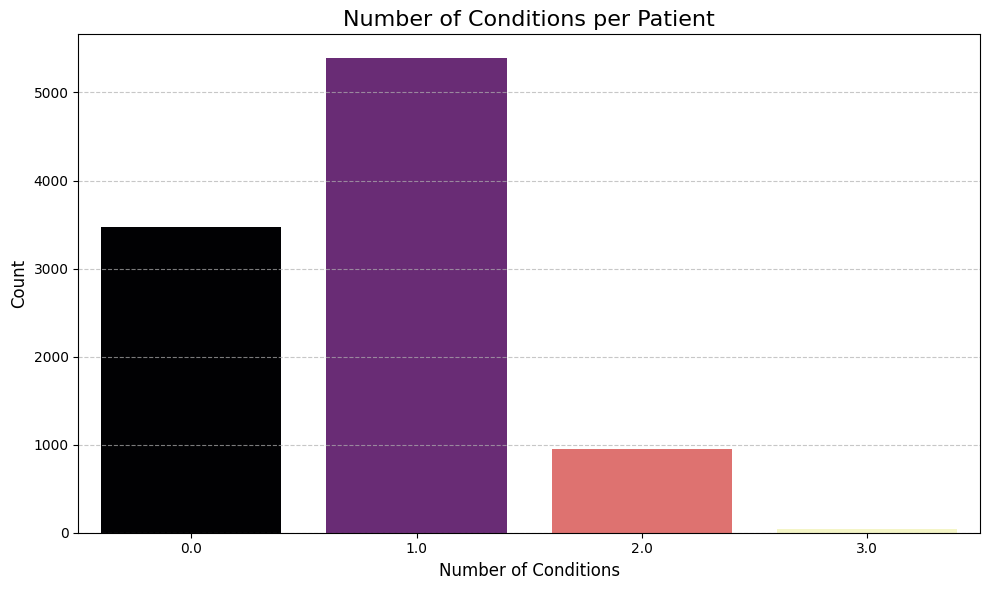

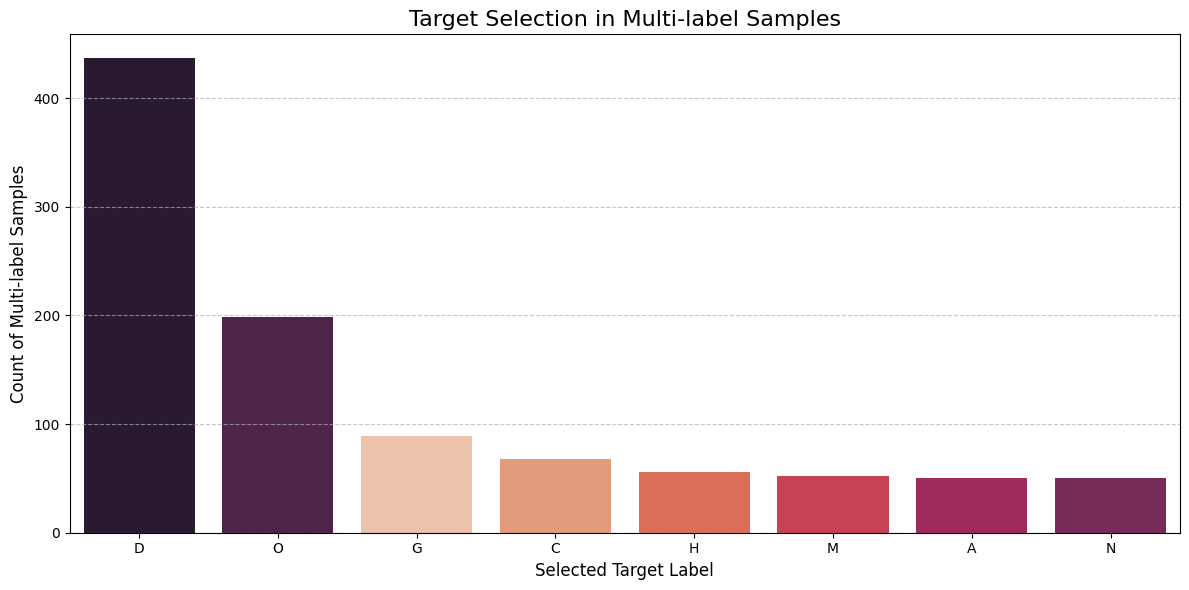

In [6]:
class_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
plot_multi_label_distribution(df, class_cols)
plot_label_correlation(df, class_cols)
plot_labels_per_sample(df, class_cols)
plot_multilabel_conflict_resolution(df, class_cols)

## 5. Random Samples from Each Class

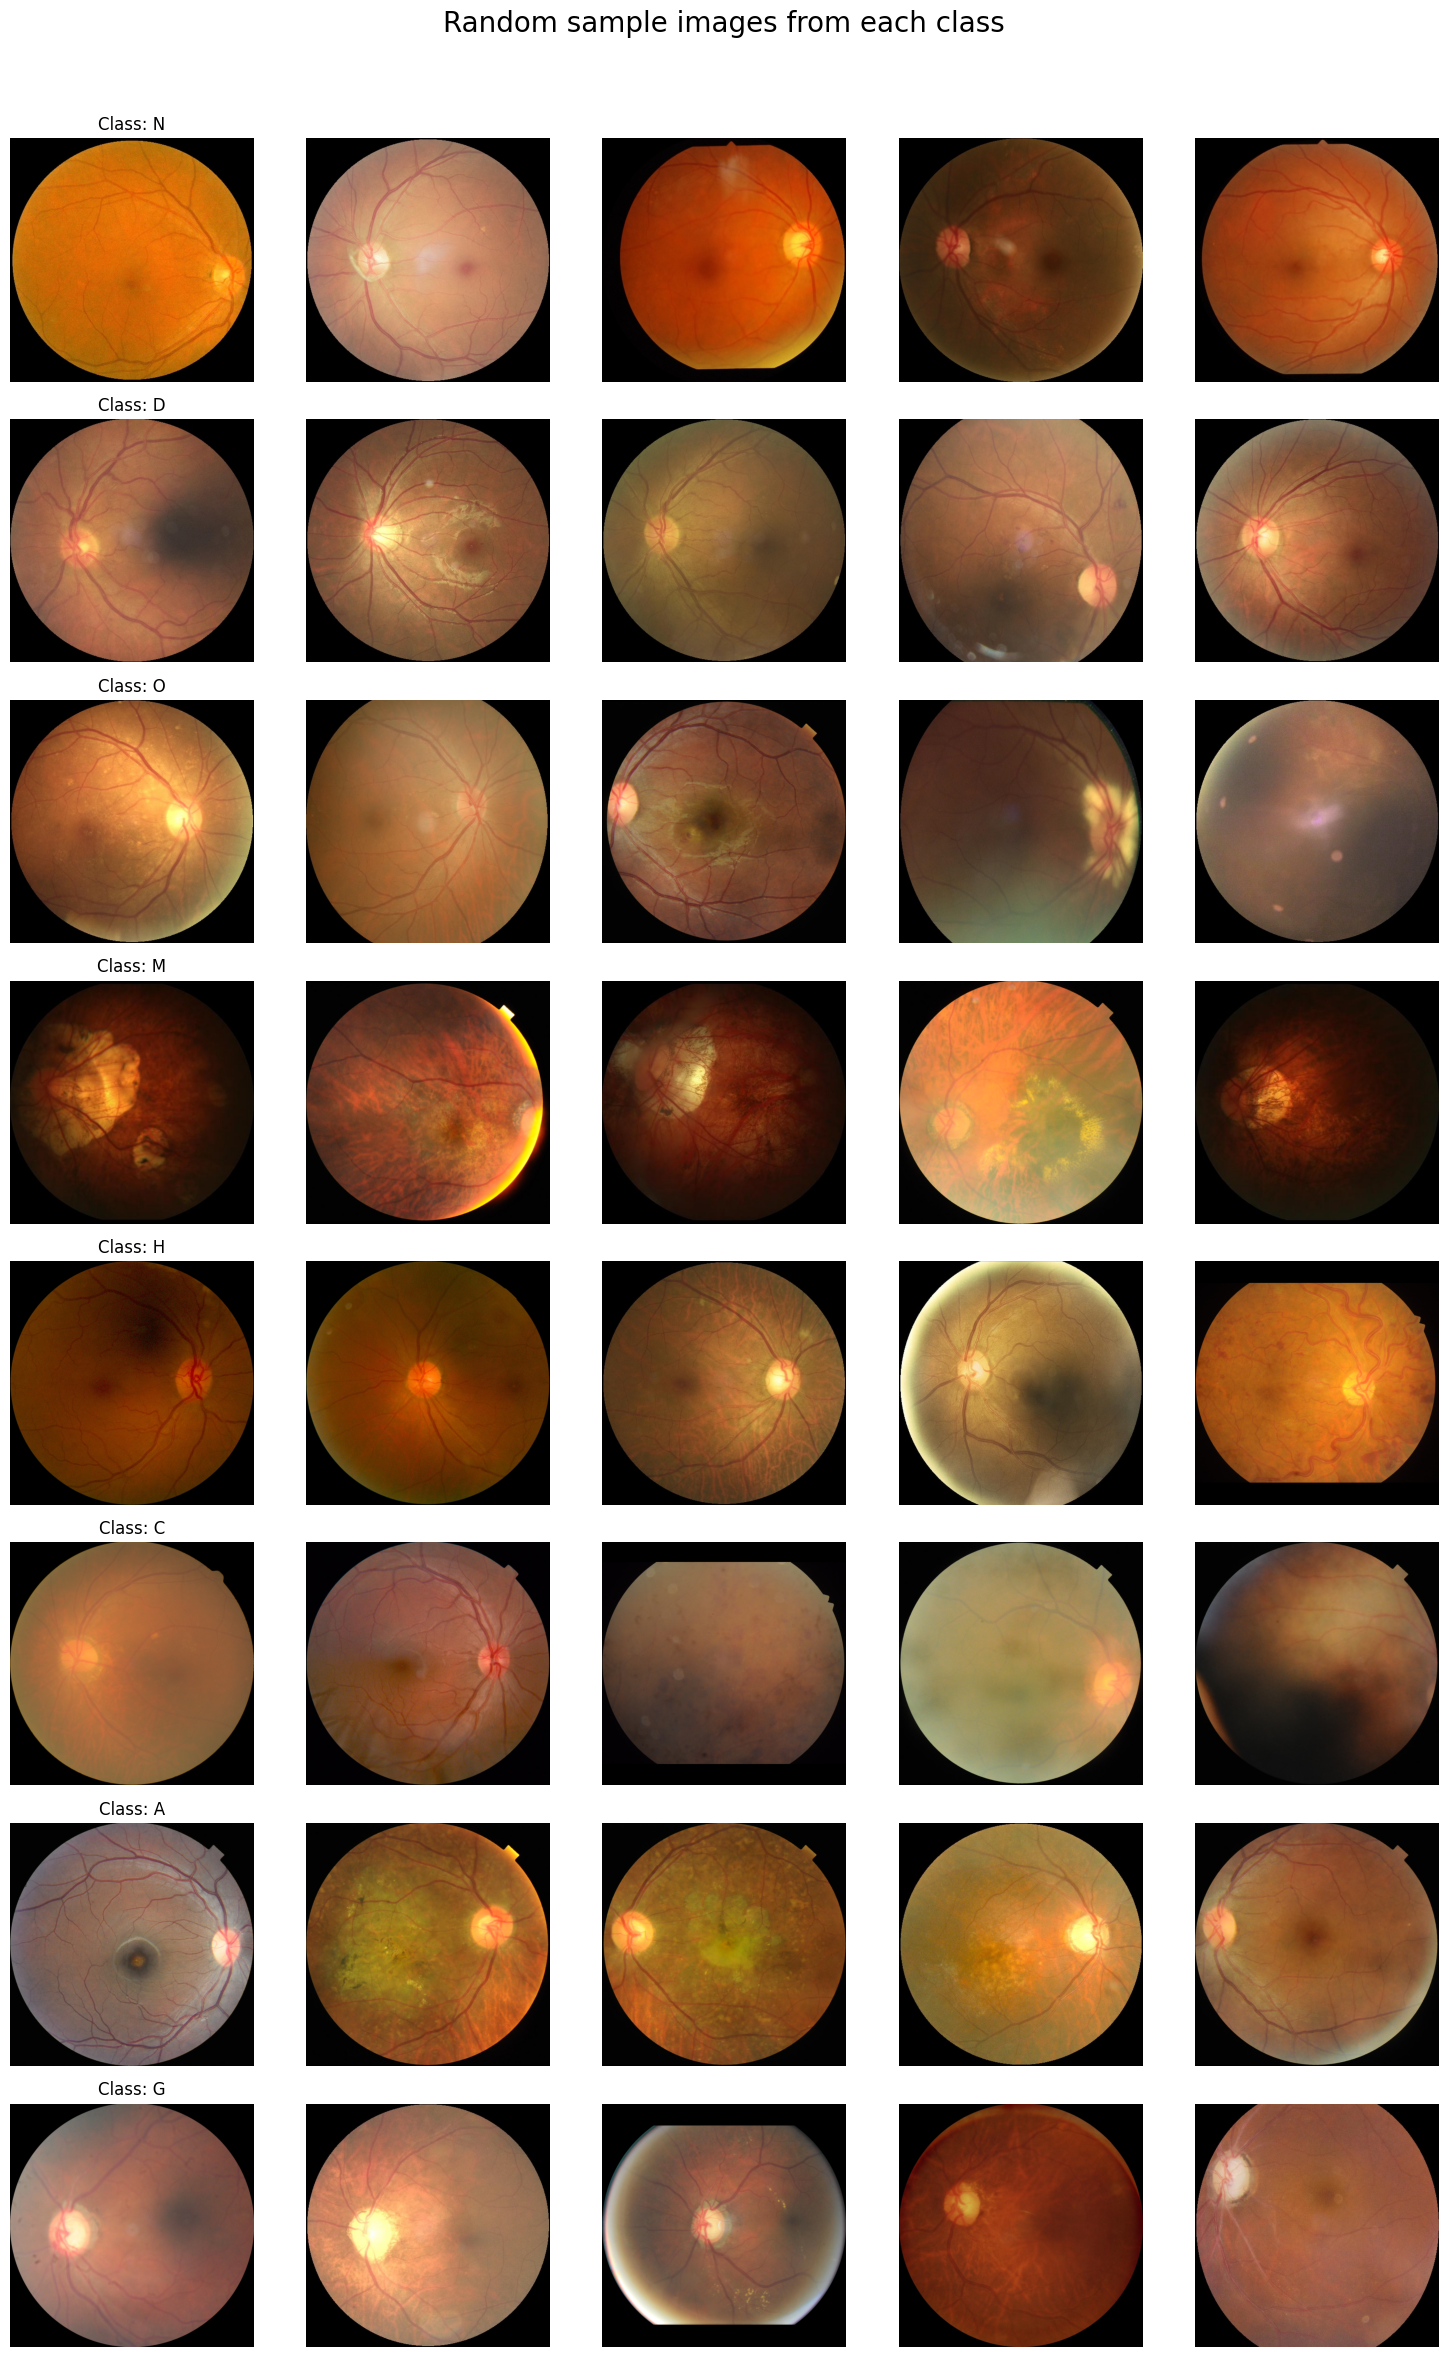

In [7]:
plot_random_samples_from_each_class(df, label_col='label', filepath_col='filepath', num_samples=5)